# Demo 1: Feedforward Neural Networks for Binary Classification
This notebook uses the **Breast Cancer Wisconsin** dataset to show:
- FFNN learning on a real-world dataset
- comparison with Logistic Regression, Random Forest, and SVM
- hyperparameter tuning for FFNN
- confusion matrix, ROC AUC, and learning curves

#### Show that tuning matters for FFNN performance.
#### Reinforce why scaling is important for FFNN, Logistic Regression, and SVM.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, ConfusionMatrixDisplay, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Load data
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("Dataset shape:", X.shape)
print("Target names:", list(data.target_names))
X.head()

Dataset shape: (569, 30)
Target names: [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Train / validation-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Training size:", X_train.shape)
print("Test size:", X_test.shape)

Training size: (426, 30)
Test size: (143, 30)


## Baseline model comparison
We scale the data for Logistic Regression, SVM, and FFNN.
Random Forest does not require scaling.

In [4]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, random_state=RANDOM_STATE
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
    ]),
    "FFNN (baseline)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(30, 15),
            activation="relu",
            solver="adam",
            alpha=0.0005, # regularization : penalize large weights alpha*Sum_w^2
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

In [5]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probabilities for ROC AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }
    results.append(row)

results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.986014,0.988889,0.988889,0.988889,0.997694
2,SVM (RBF),0.979021,0.988764,0.977778,0.983240,0.996855
1,Random Forest,0.958042,0.956522,0.977778,0.967033,0.994864
3,FFNN (baseline),0.874126,0.950000,0.844444,0.894118,0.947379


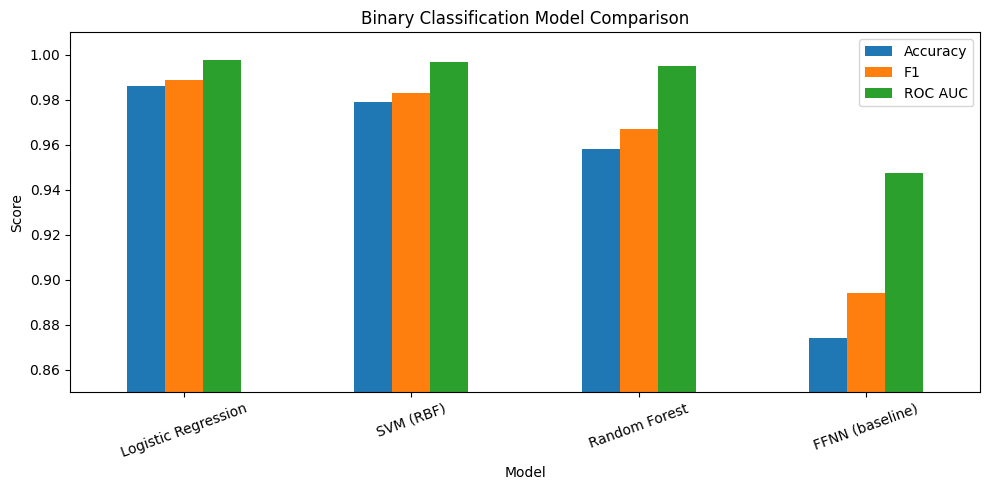

In [6]:
# Bar chart of model comparison
plot_df = results_df.set_index("Model")[["Accuracy", "F1", "ROC AUC"]]
plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Binary Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Inspect the baseline FFNN

              precision    recall  f1-score   support

   malignant       0.78      0.92      0.84        53
      benign       0.95      0.84      0.89        90

    accuracy                           0.87       143
   macro avg       0.86      0.88      0.87       143
weighted avg       0.89      0.87      0.88       143



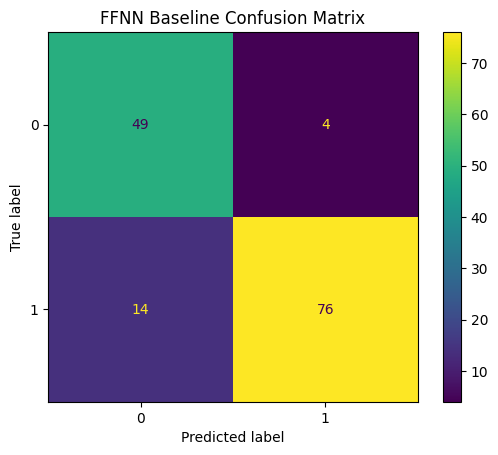

In [7]:
ffnn_baseline = models["FFNN (baseline)"]
ffnn_baseline.fit(X_train, y_train)

y_pred_ffnn = ffnn_baseline.predict(X_test)
y_prob_ffnn = ffnn_baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_ffnn, target_names=data.target_names))
ConfusionMatrixDisplay.from_estimator(ffnn_baseline, X_test, y_test)
plt.title("FFNN Baseline Confusion Matrix")
plt.show()

## Hyperparameter tuning for FFNN
We keep the search reasonably small so the notebook remains class-friendly.

In [8]:
ffnn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        solver="adam",
        activation="relu",
        max_iter=1200,
        early_stopping=True,
        random_state=RANDOM_STATE
    ))
])

param_grid = {
    "model__hidden_layer_sizes": [(20,), (40,), (30, 15), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.0005, 0.001, 0.005]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=ffnn_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("\nBest CV ROC AUC:", round(grid.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters:
{'model__alpha': 0.0001, 'model__hidden_layer_sizes': (30, 15), 'model__learning_rate_init': 0.005}

Best CV ROC AUC: 0.9892


In [9]:
tuned_ffnn = grid.best_estimator_
y_pred_tuned = tuned_ffnn.predict(X_test)
y_prob_tuned = tuned_ffnn.predict_proba(X_test)[:, 1]

tuned_results = pd.DataFrame([{
    "Model": "FFNN (tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1": f1_score(y_test, y_pred_tuned),
    "ROC AUC": roc_auc_score(y_test, y_prob_tuned)
}])

pd.concat([results_df, tuned_results], ignore_index=True).sort_values("ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.986014,0.988889,0.988889,0.988889,0.997694
1,SVM (RBF),0.979021,0.988764,0.977778,0.983240,0.996855
2,Random Forest,0.958042,0.956522,0.977778,0.967033,0.994864
4,FFNN (tuned),0.972028,0.967391,0.988889,0.978022,0.993711
3,FFNN (baseline),0.874126,0.950000,0.844444,0.894118,0.947379


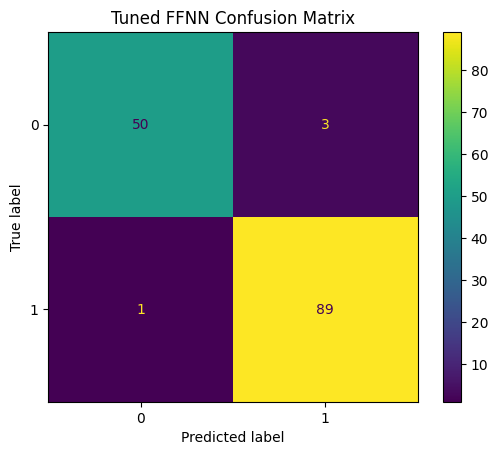

In [10]:
ConfusionMatrixDisplay.from_estimator(tuned_ffnn, X_test, y_test)
plt.title("Tuned FFNN Confusion Matrix")
plt.show()

## Learning curve for the tuned FFNN
This helps students see how performance changes as the training set grows.

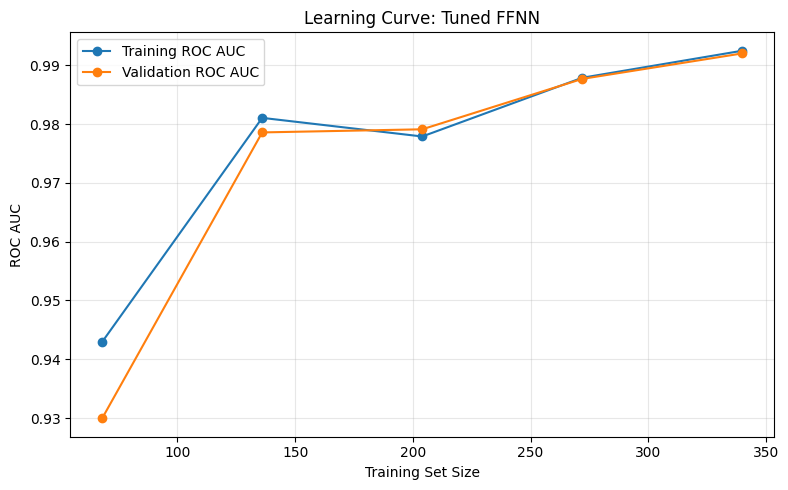

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    tuned_ffnn,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training ROC AUC")
plt.plot(train_sizes, val_mean, marker="o", label="Validation ROC AUC")
plt.xlabel("Training Set Size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve: Tuned FFNN")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()